In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

In [10]:
np.random.seed(42)
n_samples = 100000

data = pd.DataFrame({
    'Nivel_Experiencia': np.random.choice(['Bajo', 'Medio', 'Alto'], size=n_samples, p=[0.3, 0.4, 0.3]),
    'Equipamiento': np.random.choice(['Básico', 'Intermedio', 'Avanzado'], size=n_samples, p=[0.35, 0.4, 0.25]),
    'Habilidades': np.random.choice(['Bajas', 'Medias', 'Altas'], size=n_samples, p=[0.3, 0.4, 0.3]),
    'Salud': np.random.choice(['Baja', 'Media', 'Alta'], size=n_samples, p=[0.25, 0.45, 0.3]),
    'Estado_Mental': np.random.choice(['Negativo', 'Neutral', 'Positivo'], size=n_samples, p=[0.2, 0.5, 0.3]),
    'Exito_Mision': np.random.choice(['Sí', 'No'], size=n_samples, p=[0.5, 0.5])
})

In [11]:
mask_optimo = (
    (data['Nivel_Experiencia'] == 'Alto') &
    (data['Equipamiento'] == 'Avanzado') &
    (data['Habilidades'] == 'Altas') &
    (data['Salud'] == 'Alta') &
    (data['Estado_Mental'] == 'Positivo')
)
data.loc[mask_optimo, 'Exito_Mision'] = np.random.choice(
    ['Sí', 'No'], size=len(data[mask_optimo]), p=[0.95, 0.05]
)

mask_bueno = (
    (data['Nivel_Experiencia'] == 'Alto') &
    (data['Equipamiento'] == 'Avanzado') &
    ~mask_optimo  # Excluir los que ya fueron asignados
)
data.loc[mask_bueno, 'Exito_Mision'] = np.random.choice(
    ['Sí', 'No'], size=len(data[mask_bueno]), p=[0.75, 0.25]
)

mask_moderado = (
    (data['Nivel_Experiencia'] == 'Medio') &
    (data['Equipamiento'] == 'Intermedio') &
    ~mask_optimo &
    ~mask_bueno
)
data.loc[mask_moderado, 'Exito_Mision'] = np.random.choice(
    ['Sí', 'No'], size=len(data[mask_moderado]), p=[0.50, 0.50]
)

mask_malo = (
    (data['Nivel_Experiencia'] == 'Bajo') &
    (data['Equipamiento'] == 'Básico') &
    ~mask_optimo &
    ~mask_bueno &
    ~mask_moderado
)
data.loc[mask_malo, 'Exito_Mision'] = np.random.choice(
    ['Sí', 'No'], size=len(data[mask_malo]), p=[0.15, 0.85]
)

mask_pesimo = (
    (data['Nivel_Experiencia'] == 'Bajo') &
    (data['Equipamiento'] == 'Básico') &
    (data['Habilidades'] == 'Bajas') &
    (data['Salud'] == 'Baja') &
    (data['Estado_Mental'] == 'Negativo')
)
data.loc[mask_pesimo, 'Exito_Mision'] = np.random.choice(
    ['Sí', 'No'], size=len(data[mask_pesimo]), p=[0.05, 0.95]
)

mask_mental_neg = (data['Estado_Mental'] == 'Negativo') & ~mask_pesimo
data.loc[mask_mental_neg, 'Exito_Mision'] = np.random.choice(
    ['Sí', 'No'], size=len(data[mask_mental_neg]), p=[0.20, 0.80]
)

mask_mental_pos = (data['Estado_Mental'] == 'Positivo')
mask_mental_pos_updated = mask_mental_pos & ~mask_optimo & ~mask_mental_neg
if len(data[mask_mental_pos_updated]) > 0:
    data.loc[mask_mental_pos_updated, 'Exito_Mision'] = np.random.choice(
        ['Sí', 'No'], size=len(data[mask_mental_pos_updated]), p=[0.65, 0.35]
    )

In [12]:
# Codificar variables categóricas
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
data_encoded = data.copy()
data_encoded[['Nivel_Experiencia', 'Equipamiento', 'Habilidades', 'Salud', 'Estado_Mental']] = encoder.fit_transform(
    data[['Nivel_Experiencia', 'Equipamiento', 'Habilidades', 'Salud', 'Estado_Mental']]
)

# Codificar la variable objetivo
target_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
data_encoded[['Exito_Mision']] = target_encoder.fit_transform(data[['Exito_Mision']])

In [13]:
# Entrenar modelo Naive Bayes Categórico
X = data_encoded[['Nivel_Experiencia', 'Equipamiento', 'Habilidades', 'Salud', 'Estado_Mental']].values.astype(int)
y = data_encoded['Exito_Mision'].values.astype(int).flatten()

model = CategoricalNB()
model.fit(X, y)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


In [14]:
# Crear todas las combinaciones posibles de Nivel_Experiencia y Equipamiento
levels = ['Bajo', 'Medio', 'Alto']
equipos = ['Básico', 'Intermedio', 'Avanzado']

combinations = []
for level in levels:
    for equipo in equipos:
        combinations.append({
            'Nivel_Experiencia': level,
            'Equipamiento': equipo,
            'Habilidades': 'Medias',  # Valor por defecto
            'Salud': 'Media',          # Valor por defecto
            'Estado_Mental': 'Neutral' # Valor por defecto
        })

combinations_df = pd.DataFrame(combinations)

# Codificar las combinaciones
combinations_encoded = combinations_df.copy()
combinations_encoded[['Nivel_Experiencia', 'Equipamiento', 'Habilidades', 'Salud', 'Estado_Mental']] = encoder.transform(
    combinations_df[['Nivel_Experiencia', 'Equipamiento', 'Habilidades', 'Salud', 'Estado_Mental']]
)

# Predecir probabilidades
X_combinations = combinations_encoded[['Nivel_Experiencia', 'Equipamiento', 'Habilidades', 'Salud', 'Estado_Mental']].values.astype(int)
probabilities = model.predict_proba(X_combinations)

combinations_df['P(Fracaso)'] = probabilities[:, 0]
combinations_df['P(Éxito)'] = probabilities[:, 1]

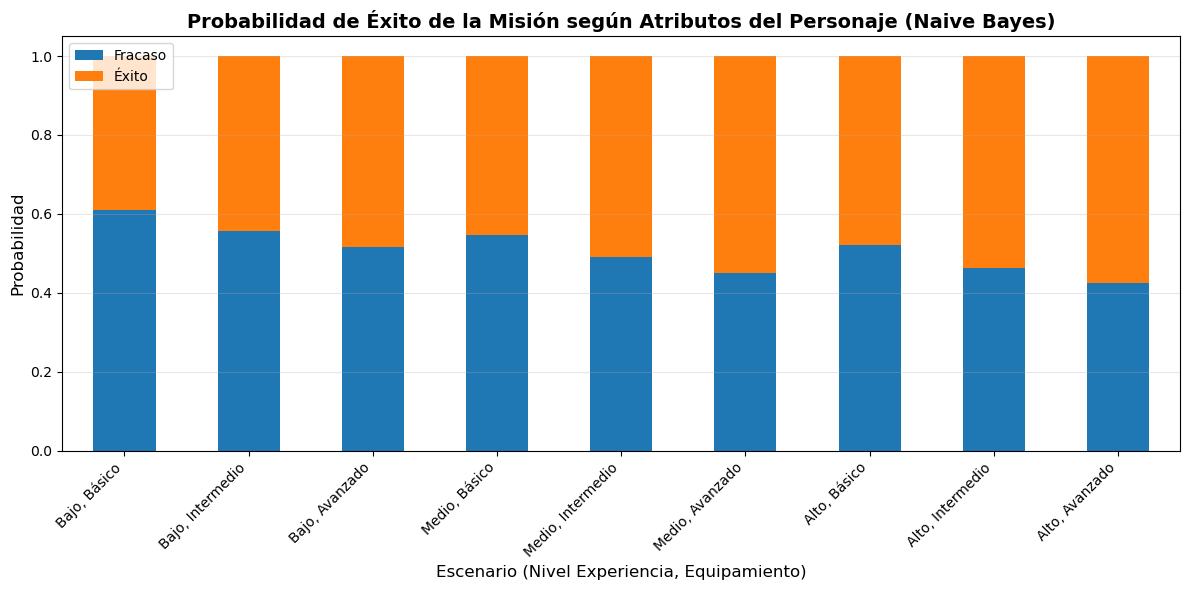

In [15]:
# Crear gráfica
combinations_df['Escenario'] = combinations_df.apply(
    lambda row: f"{row['Nivel_Experiencia']}, {row['Equipamiento']}", axis=1
)

combinations_df.plot(
    x='Escenario',
    y=['P(Fracaso)', 'P(Éxito)'],
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Probabilidad de Éxito de la Misión según Atributos del Personaje (Naive Bayes)', fontsize=14, fontweight='bold')
plt.xlabel('Escenario (Nivel Experiencia, Equipamiento)', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Fracaso', 'Éxito'], loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('probabilidades_condicionales_mision_naive_bayes.png', dpi=300, bbox_inches='tight')
plt.show()